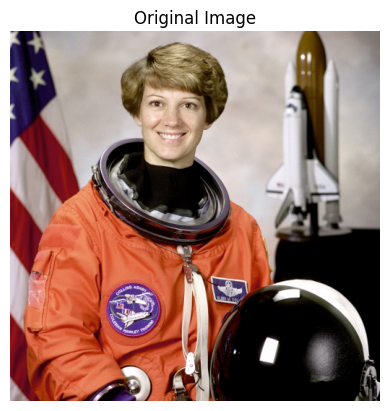

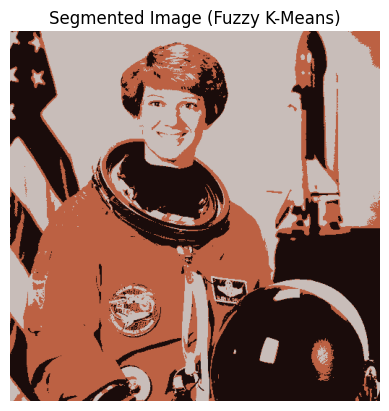

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from skfuzzy.cluster import cmeans
from skimage import data

# Step 1: Load an inbuilt image dataset
image = data.astronaut()   # Inbuilt RGB image

# Step 2: Display original image
plt.figure()
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')

# Step 3: Reshape image into pixel data
pixels = image.reshape((-1, 3))   # Convert to (num_pixels, RGB)
pixels = np.float32(pixels)

# Step 4: Transpose data for FCM (features, samples)
pixels = pixels.T

# Step 5: Set number of clusters
c =  3 # Number of segments

# Step 6: Apply Fuzzy C-Means clustering
cntr, u, u0, d, jm, p, fpc = cmeans(
    pixels,
    c,
    2,              # Fuzziness coefficient (m)
    error=0.005,
    maxiter=1000,
    init=None
)

# Step 7: Get cluster membership (max value)
cluster_membership = np.argmax(u, axis=0)

# Step 8: Convert cluster centers to integer
cntr = np.uint8(cntr)

# Step 9: Map each pixel to its cluster center
segmented_data = cntr[cluster_membership]

# Step 10: Reshape back to image
segmented_image = segmented_data.reshape(image.shape)

# Step 11: Display segmented image
plt.figure()
plt.title("Segmented Image (Fuzzy K-Means)")
plt.imshow(segmented_image)
plt.axis('off')

# Show both images
plt.show()